<a href="https://colab.research.google.com/github/JohnAndrewCB/Machine-Learning/blob/main/Notebooks/Hands_on2_ChavezBaltazarJuanAndre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Lineal Simple (SLR) en Machine Learning

## Fundamentos teóricos

La regresión lineal la describen como un “método estadístico que se utiliza para el análisis predictivo”, yo la describiría como un modelo predictivo de tipo “regresión”.

Un modelo es la representación que deduces después de analizar un conjunto de datos y que te permite describir, explicar o predecir la realidad. En este caso SLR, es específicamente de tipo predictivo; Y como se busca predecir un dato de tipo numérico (ya sea de intervalo o de proporción) es un modelo predictivo de **regresión**.

Como la relación entre variables es lineal, es conveniente  creer que el modelo (matemático) se comporte como la recta:

yi = b₀ + b₁xi + ε

Donde:
- y = variable dependiente
- x = variable independiente
- b₀ = punto de intersección con el eje “y” (grado de libertad)
- b₁ = pendiente de la recta (m)
- ε = término de error ( (y - ŷ)² )

Nota: La recta no "pasará" sobre todos los puntos (datos); por lo que, esas diferencias de distancias entre la recta construida y los datos, no se pasa por alto (ε).

### Tipos de regresión lineal
- Lineal simple: Se modela la relación lineal entre dos variables. Una variable dependiente a una variable independiente.
- Lineal múltiple: Hay una relación lineal entre más de dos variables. Una variable dependiente de más de una variable independiente.  


### Planteamiento del problema: Salario V/S Experiencia

Ejemplo de aplicación:

Veremos un conjunto de datos con dos variables: salario (la variable dependiente) y experiencia (la variable independiente). Los objetivos de este problema son los siguientes:

Queremos ver si existe alguna relación entre estas dos variables y cómo el cambio de la variable independiente afecta a la variable dependiente. En esta sección, construiremos un modelo de regresión lineal simple para determinar qué línea representa mejor la relación entre estas dos variables.

#### 1. Procesamiento de datos

In [2]:
# importamos librerias
import numpy as np                # numpy (cálculo numérico/operaciones matemáticas)
import pandas as pd               # pandas (estructurar los datos/filtrar, ordenar, transformar datos, leer data set's)

import matplotlib.pyplot as plt   # matplotlib (gráficos para representar datos)
%matplotlib inline

import seaborn as sns             # seaborn (gráficos estadísticos más avanzados)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# read archivo (en este caso es un .CSV)
filepath = "/content/drive/MyDrive/Colab Notebooks/Machine Learning by School TEC/Data Sets/Salary_Data.csv"
df = pd.read_csv(filepath)

In [12]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


<Axes: xlabel='YearsExperience', ylabel='Salary'>

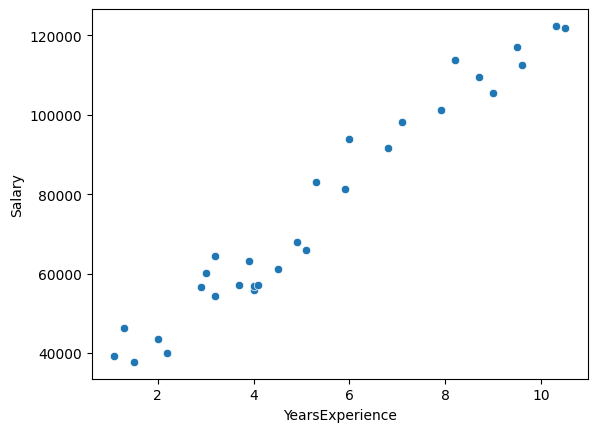

In [13]:
sns.scatterplot(x=df.YearsExperience, y = df.Salary)

Mirando el gráfico, podemos ver que el salario (y) y los años de experiencia (x) tienen una conexión lineal y están correlacionados (si los años de experiencia varian, el salario también lo hará); por lo que, la naturaleza del modelo es lineal.

Utilicemos la información proporcionada para predecir con más detalle el salario en función del año de experiencia.

A continuación, debemos extraer las variables dependientes e independientes del conjunto de datos dado.

La variable independiente son los años de experiencia y la variable dependiente es el salario.

In [14]:
x = df.iloc[:,:-1]      #  variable independiente (años de experiencia)
y = df.iloc[:,1:]       # variable dependiente (salario)

print(x.shape)          # un vector columna

(30, 1)


Dado que hemos extraído la variable independiente (x) y la variable dependiente (y), dividiremos ambas variables en conjuntos de entrenamiento y prueba. Tenemos 30 observaciones, por lo que utilizaremos 20 para el conjunto de entrenamiento y 10 para el conjunto de prueba. Estamos separando nuestro conjunto de datos para poder entrenar nuestro modelo en un conjunto de datos y luego probarlo en otro.

In [15]:
# splitting the dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=0)
print(x_train.shape)
print(y_test.shape)

(20, 1)
(10, 1)


In [16]:
x_train

,YearsExperience
5,2.9
16,5.1
8,3.2
14,4.5
23,8.2
20,6.8
1,1.3
29,10.5
6,3.0
4,2.2


#### 2. Ajuste de la regresión lineal simple al conjunto de entrenamiento

Ahora el siguiente paso es encontrar la línea de mejor ajuste donde la diferencia entre los valores predichos y los valores reales sea mínima. Para lograrlo, importaremos la clase LinearRegression del paquete de modelo lineal de sci-kit learn. Después de importar la clase, construiremos un objeto de clase regresora.

In [17]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()    # creamos el objeto de tipo "LinearRegression"

regressor.fit(x_train,y_train)    # calculamos coeficientes de la recta (B0, B1)

LinearRegression()

In [18]:
# obtenemos la pendiente, o sea por cada aumento de 1 unidad en "x" se aumenta aprox 9345.94... en y. (B1)
regressor.coef_

array([[9345.94244312]])

In [19]:
# obtenemos la intersección de la recta (B0)
regressor.intercept_

array([26816.19224403])

Ajustamos nuestro objeto regresor al conjunto de entrenamiento para que el modelo pueda aprender fácilmente las correlaciones entre las variables predictoras y objetivo.

#### 3. Predicción del resultado del conjunto de pruebas

Como resultado, nuestro modelo ahora está preparado para predecir los resultados de las nuevas observaciones. En esta etapa, le daremos al modelo un conjunto de datos de prueba (nuevas observaciones) para ver si puede predecir el resultado previsto.

Creamos un vector de predicción llamado y_pred y x_pred, que contiene predicciones para el conjunto de datos de prueba y el conjunto de entrenamiento, respectivamente.

In [20]:
# predicción de prueba y entrenamiento

x_pred = regressor.predict(x_train)
y_pred = regressor.predict(x_test)

### 4. Visualización de los resultados del conjunto de entrenamiento

Ahora creamos la representación del modelo (en este caso una recta) en el conjunto de datos analizado.

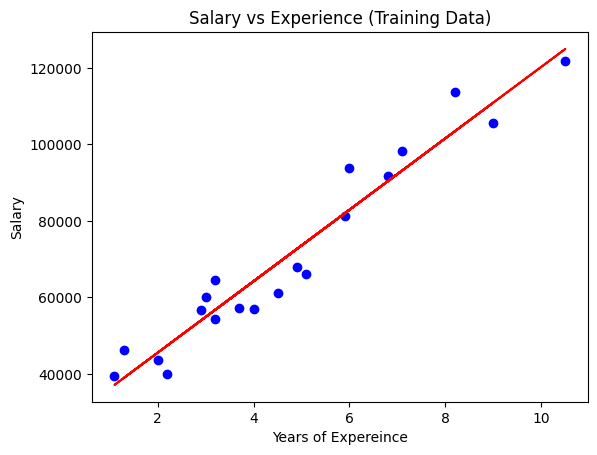

In [21]:
plt.scatter(x_train, y_train,color='blue')
plt.plot(x_train, x_pred, color= 'red')

plt.title("Salary vs Experience (Training Data)")
plt.xlabel('Years of Expereince')
plt.ylabel('Salary')
plt.show()

Las observaciones de valores reales se muestran en puntos azules en el gráfico anterior, mientras que los valores predichos están cubiertos por la línea de regresión roja.

El buen ajuste de la línea se puede ver calculando la diferencia entre los valores reales y los construidos por el modelo. Sin embargo, como se ve en el gráfico adjunto, la mayoría de las observaciones están cerca de la línea de regresión, lo que indica que nuestro modelo es adecuado para el conjunto de entrenamiento.

#### 5. Visualización del conjunto de pruebas

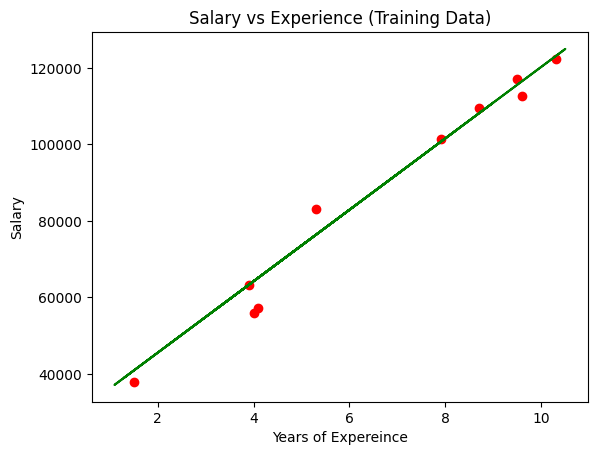

In [22]:
plt.scatter(x_test,y_test,color='red')  # Graficamos los puntos con los datos de prueba
plt.plot(x_train, x_pred, color= 'green')   # Recta construida por el modelo entrenado

plt.title("Salary vs Experience (Training Data)")
plt.xlabel('Years of Expereince')
plt.ylabel('Salary')
plt.show()

El color rojo en el gráfico anterior representa las observaciones y la línea de regresión verde representa la predicción. Como podemos ver, la mayoría de las observaciones están cerca de la línea de regresión, por lo que podemos concluir que nuestra Regresión Lineal Simple es un buen modelo capaz de hacer predicciones precisas.